# YOLOv8 + Preprocesamiento Espinal
## Modelo E — YOLOv8m con curvas de columna (dataset filtrado)

| | A | B | B+ | C | D | **E** |
|---|---|---|---|---|---|---|
| **Arquitectura** | YOLOv8m | YOLOv8m | YOLOv8m | MaskRCNN | MaskRCNN | **YOLOv8m** |
| **Dataset** | Completo | Filtrado | Filtrado | Filtrado | Completo | **Filtrado** |
| **Preproc** | Ninguno | Ninguno | Ninguno | Curva+CLAHE | Curva+CLAHE | **Curva+CLAHE** |
| **Dice** | 0.29 | 0.39 | 0.37 | 0.13* | 0.10* | **?** |

### Hipótesis
YOLOv8 ya demostró Dice=0.39 sin preprocesamiento (Modelo B).
El preprocesamiento espinal:
- Centra la columna en el canvas → YOLOv8 no pierde tiempo con fondo irrelevante
- CLAHE mejora el contraste local de las vértebras
- El mapa espinal guiado por la curva realza la región vertebral
- Preserva aspect ratio → no distorsiona la morfología vertebral

### Diferencia clave vs MaskRCNN
YOLOv8 usa el formato de segmentación propio (polígonos normalizados),
no COCO JSON. Las imágenes preprocesadas se guardan en disco y se pasan
directamente al entrenador de ultralytics.

### Rutas
```
Scoliosis_Dataset/
  Normal/ Scoliosis/            ← radiografías originales
  LabelMultiClass_ID_PNG/       ← máscaras IDs 0-17
  LabelBinaryJPG/               ← máscara binaria columna
  RadiographMetrics/curvas_en_pixeles/  ← curva_{patient_id}.csv
  indice_dataset.csv
```

## 0 — Instalación

In [ ]:
!pip install -q ultralytics
import torch
print(f'PyTorch: {torch.__version__}  CUDA: {torch.version.cuda}')
print(f'GPU:     {torch.cuda.get_device_name(0)}')
print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128  CUDA: 12.8
GPU:     Tesla T4
VRAM:    15.6 GB


In [ ]:

import torch

print(f'PyTorch: {torch.__version__}  CUDA: {torch.version.cuda}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print("GPU no disponible, usando CPU")


PyTorch: 2.10.0+cu128  CUDA: 12.8
GPU: Tesla T4


In [ ]:
import os, shutil, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy.interpolate import UnivariateSpline
from collections import Counter
from ultralytics import YOLO
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ── RUTAS (idénticas al notebook YOLOv8 original) ─────────────
DRIVE_ROOT    = Path('/content/drive/MyDrive')
DATASET_ROOT  = DRIVE_ROOT / 'Scoliosis_Dataset'
CSV_PATH      = DATASET_ROOT / 'indice_dataset.csv'
METRICS_DIR   = DATASET_ROOT / 'RadiographMetrics'
CURVAS_DIR    = METRICS_DIR / 'curvas_en_pixeles'
YOLO_DS_FILT  = Path('/content/yolo_spine/dataset_filtered')  # Dataset B previo

# Directorio de trabajo para este notebook
WORK_DIR      = Path('/content/yolo_preproc')
YOLO_DS_E     = WORK_DIR / 'dataset_E'    # filtrado + preprocesado
YOLO_DS_F     = WORK_DIR / 'dataset_F'    # completo + preprocesado
RUNS_DIR      = WORK_DIR / 'runs'
IMG_PROC_DIR  = WORK_DIR / 'images_preprocessed'

# ── COLUMNAS CSV ──────────────────────────────────────────────
COL_SPLIT = 'split'
COL_IMAGE = 'radiograph_path'
COL_MASK  = 'multiclass_id_png'
COL_BINARY= 'label_binary_path'

# ── CLASES ────────────────────────────────────────────────────
CLASS_NAMES     = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10',
                   'T11','T12','L1','L2','L3','L4','L5']
NUM_CLASSES     = 17
MASK_ID_TO_YOLO = {i: i-1 for i in range(1, 18)}  # máscara 1-based → YOLO 0-based
IMG_SIZE        = 1024
SEED            = 42

random.seed(SEED)
np.random.seed(SEED)
for ds in [YOLO_DS_E, YOLO_DS_F]:
    for split in ['train', 'val', 'test']:
        (ds / 'images' / split).mkdir(parents=True, exist_ok=True)
        (ds / 'labels' / split).mkdir(parents=True, exist_ok=True)

print('✔ Configuración lista')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
✔ Configuración lista


---
## 1 — Carga de Curvas de Columna

Mismo formato confirmado del notebook MaskRCNN:
- `curvas_en_pixeles/curva_pixeles_{patient_id}.csv` — columnas `x_px`, `y_px`
- 178/249 imágenes tienen curva; el resto recibe solo CLAHE+crop

In [ ]:
df = pd.read_csv(CSV_PATH, sep=';')
print(f'Total imágenes: {len(df)}')

# Construir cache de curvas
CURVE_CACHE = {}
for _, row in df.iterrows():
    pid      = int(row['patient_id'])
    csv_path = CURVAS_DIR / f'curva_pixeles_{pid}.csv'
    if csv_path.exists():
        df_c = pd.read_csv(csv_path)
        CURVE_CACHE[pid] = df_c[['x_px', 'y_px']].values.astype(np.float32)

print(f'✔ Curvas cargadas: {len(CURVE_CACHE)}/{len(df)}')
print(f'  Sin curva: {len(df)-len(CURVE_CACHE)} imágenes (recibirán solo CLAHE+crop)')

def load_spine_curve(image_stem):
    matches = df[df[COL_IMAGE].apply(lambda p: Path(p).stem == image_stem)]
    if len(matches) == 0: return None
    pid = int(matches.iloc[0]['patient_id'])
    return CURVE_CACHE.get(pid, None)

# Verificar
for stem in ['N_6', 'S_21']:
    c = load_spine_curve(stem)
    print(f'  {stem}: {c.shape[0]} puntos' if c is not None else f'  {stem}: sin curva')

Total imágenes: 249
✔ Curvas cargadas: 178/249
  Sin curva: 71 imágenes (recibirán solo CLAHE+crop)
  N_6: sin curva
  S_21: 719 puntos


---
## 2 — Preprocesamiento Espinal

Pipeline idéntico al notebook MaskRCNN (versión corregida con fix de rotación):
1. CLAHE → mejora contraste local
2. Mapa de probabilidad espinal (spline sobre curva) → realce gaussiano
3. Crop ROI con corrección de rotación → elimina fondo
4. Resize preservando aspect ratio → padding negro

**Diferencia vs MaskRCNN:** la salida se guarda como JPG para YOLOv8,
no se necesita COCO JSON.

In [ ]:
def build_spine_probability_map(curve_pts, h, w, sigma_x=45):
    prob_map = np.zeros((h, w), dtype=np.float32)
    pts = curve_pts[np.argsort(curve_pts[:, 1])]
    ys  = pts[:, 1].astype(float)
    xs  = pts[:, 0].astype(float)
    _, unique_idx = np.unique(ys, return_index=True)
    ys = ys[unique_idx]; xs = xs[unique_idx]
    if len(ys) < 4: return prob_map
    try:
        spline = UnivariateSpline(ys, xs, k=min(3, len(ys)-1), s=len(ys)*10)
    except Exception:
        spline = lambda y: np.interp(y, ys, xs)
    all_y    = np.arange(h, dtype=float)
    center_x = np.clip(spline(all_y), 0, w-1)
    x_grid   = np.arange(w, dtype=float)
    for row_y in range(h):
        prob_map[row_y] = np.exp(-0.5 * ((x_grid - center_x[row_y]) / sigma_x)**2)
    return prob_map


def preprocess_image(img_path, binary_path, curve_pts,
                     target_size=(512, 1024),
                     use_spine_map=True,
                     spine_map_alpha=0.3):
    """
    Preprocesamiento espinal con fix de rotación y preservación de aspect ratio.
    target_size = (W, H)
    """
    img = cv2.imread(str(img_path))
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H_img, W_img = gray.shape

    # 1. CLAHE
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # 2. Mapa espinal
    if use_spine_map and curve_pts is not None and len(curve_pts) >= 4:
        prob_map   = build_spine_probability_map(curve_pts, H_img, W_img, sigma_x=45)
        enhanced_f = enhanced.astype(np.float32) * (1.0 + spine_map_alpha * prob_map)
        enhanced   = np.clip(enhanced_f, 0, 255).astype(np.uint8)

    # 3. Crop ROI con corrección de rotación
    binary = cv2.imread(str(binary_path), cv2.IMREAD_GRAYSCALE)
    if binary is not None:
        H_bin, W_bin = binary.shape
        if (H_bin >= W_bin) != (H_img >= W_img):
            binary = cv2.rotate(binary, cv2.ROTATE_90_CLOCKWISE)
            H_bin, W_bin = binary.shape
        if (H_bin, W_bin) != (H_img, W_img):
            binary = cv2.resize(binary, (W_img, H_img), interpolation=cv2.INTER_NEAREST)
        binary_bin = (binary > 127).astype(np.uint8)
        rows = np.any(binary_bin, axis=1)
        cols = np.any(binary_bin, axis=0)
        if rows.any():
            y1, y2 = np.where(rows)[0][[0,-1]]
            x1, x2 = np.where(cols)[0][[0,-1]]
            dy = max(1, int((y2-y1)*0.08))
            dx = max(1, int((x2-x1)*0.08))
            x1=max(0,x1-dx); x2=min(W_img,x2+dx)
            y1=max(0,y1-dy); y2=min(H_img,y2+dy)
            enhanced = enhanced[y1:y2, x1:x2]

    # 4. Resize preservando aspect ratio + padding negro
    tw, th   = target_size
    h_crop, w_crop = enhanced.shape[:2]
    scale    = min(tw / w_crop, th / h_crop)
    new_w    = int(w_crop * scale)
    new_h    = int(h_crop * scale)
    resized  = cv2.resize(enhanced, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas   = np.zeros((th, tw), dtype=np.uint8)
    pad_y    = (th - new_h) // 2
    pad_x    = (tw - new_w) // 2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized

    # YOLOv8 necesita 3 canales
    return cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)


print('✔ Funciones de preprocesamiento definidas')

✔ Funciones de preprocesamiento definidas


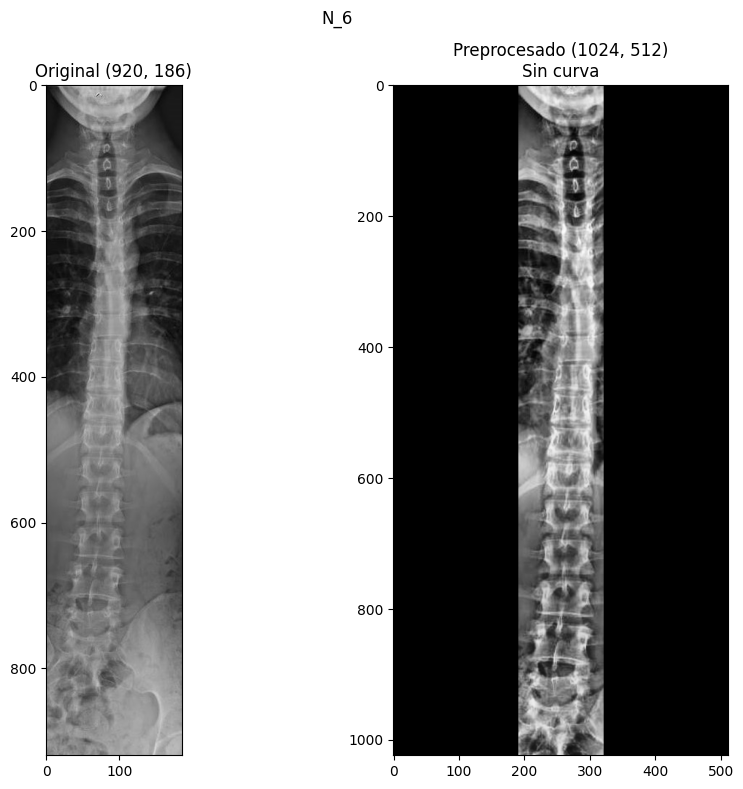

N_6: proc shape=(1024, 512, 3)


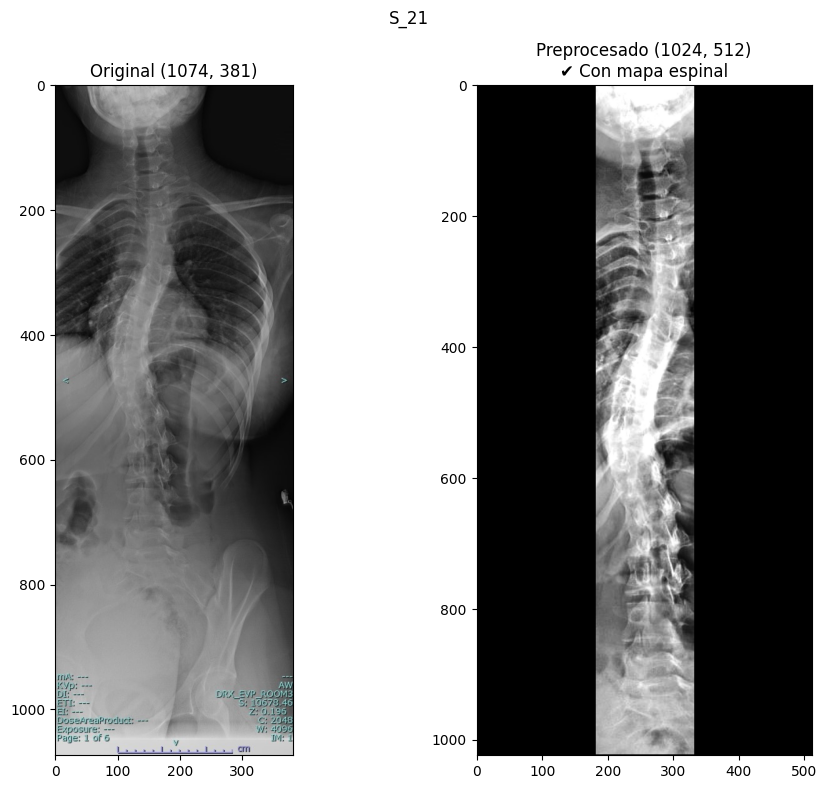

S_21: proc shape=(1024, 512, 3)


In [ ]:
# ── Verificación visual ───────────────────────────────────────
for stem in ['N_6', 'S_21']:
    row = df[df[COL_IMAGE].apply(lambda p: Path(p).stem == stem)]
    if len(row) == 0: continue
    row   = row.iloc[0]
    ip    = DATASET_ROOT / row[COL_IMAGE]
    bp    = DATASET_ROOT / row[COL_BINARY]
    curve = load_spine_curve(stem)
    orig  = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
    proc  = preprocess_image(ip, bp, curve, use_spine_map=True)
    proc_rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    axes[0].imshow(orig);     axes[0].set_title(f'Original {orig.shape[:2]}')
    axes[1].imshow(proc_rgb); axes[1].set_title(
        f'Preprocesado {proc_rgb.shape[:2]}\n{"✔ Con mapa espinal" if curve is not None else "Sin curva"}')
    plt.suptitle(stem); plt.tight_layout(); plt.show()
    print(f'{stem}: proc shape={proc.shape}')

---
## 3 — Split y Filtrado

In [ ]:
print(df[COL_SPLIT].value_counts().to_string())
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df[COL_SPLIT], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df[COL_SPLIT], random_state=SEED
)
for d in [train_df, val_df, test_df]:
    d.reset_index(drop=True, inplace=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

split
Scoliosis    178
Normal        71
Train: 174 | Val: 37 | Test: 38


In [ ]:
# Filtrado: reutilizar Dataset B o filtrar desde máscaras PNG
def stems_from_yolo(yolo_filt, split):
    d = Path(yolo_filt) / 'labels' / split
    return {p.stem for p in d.glob('*.txt')} if d.exists() else set()

def has_min_classes(mask_path, min_classes=13):
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None: return False
    if m.ndim == 3: m = m[:,:,0]
    present = set(int(v) for v in np.unique(m) if v > 0)
    return all(i in present for i in range(1, min_classes+1))

def filter_df(df, stems):
    return df[df[COL_IMAGE].apply(
        lambda p: Path(p).stem in stems
    )].reset_index(drop=True)

train_stems = stems_from_yolo(YOLO_DS_FILT, 'train')
if not train_stems:
    print('Dataset B no encontrado — filtrando desde máscaras PNG (~3 min)...')
    complete_stems = set()
    for _, row in pd.concat([train_df, val_df, test_df]).iterrows():
        if has_min_classes(DATASET_ROOT / row[COL_MASK]):
            complete_stems.add(Path(row[COL_IMAGE]).stem)
    train_stems = val_stems = test_stems = complete_stems
    print(f'  Imágenes completas: {len(complete_stems)}')
else:
    val_stems  = stems_from_yolo(YOLO_DS_FILT, 'val')
    test_stems = stems_from_yolo(YOLO_DS_FILT, 'test')
    print('Dataset B encontrado en disco')

# Dataset E: filtrado + preprocesado
train_f = filter_df(train_df, train_stems)
val_f   = filter_df(val_df,   val_stems)
test_f  = filter_df(test_df,  test_stems)

# Dataset F: completo + preprocesado
train_full = train_df.copy()
val_full   = val_df.copy()
test_full  = test_df.copy()

print(f'\nDataset E (filtrado+preproc): Train={len(train_f)} Val={len(val_f)} Test={len(test_f)}')
print(f'Dataset F (completo+preproc): Train={len(train_full)} Val={len(val_full)} Test={len(test_full)}')

Dataset B no encontrado — filtrando desde máscaras PNG (~3 min)...
  Imágenes completas: 153

Dataset E (filtrado+preproc): Train=104 Val=24 Test=25
Dataset F (completo+preproc): Train=174 Val=37 Test=38


---
## 4 — Construir Datasets YOLOv8 con Imágenes Preprocesadas

Diferencia clave vs Dataset B original:
- Las imágenes guardadas son las **preprocesadas** (CLAHE+mapa+crop)
- Los labels YOLO son los mismos polígonos normalizados
- Las coordenadas de los polígonos se recalculan sobre la imagen preprocesada
  para mantener la alineación correcta

In [ ]:
def compute_crop_params(binary_path, img_h, img_w, margin=0.08):
    """Calcula parámetros de crop ROI. Retorna (x1,y1,x2,y2) o None."""
    binary = cv2.imread(str(binary_path), cv2.IMREAD_GRAYSCALE)
    if binary is None: return None
    H_bin, W_bin = binary.shape
    if (H_bin >= W_bin) != (img_h >= img_w):
        binary = cv2.rotate(binary, cv2.ROTATE_90_CLOCKWISE)
        H_bin, W_bin = binary.shape
    if (H_bin, W_bin) != (img_h, img_w):
        binary = cv2.resize(binary, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
    binary_bin = (binary > 127).astype(np.uint8)
    rows = np.any(binary_bin, axis=1)
    cols = np.any(binary_bin, axis=0)
    if not rows.any(): return None
    y1, y2 = np.where(rows)[0][[0,-1]]
    x1, x2 = np.where(cols)[0][[0,-1]]
    dy = max(1, int((y2-y1)*margin))
    dx = max(1, int((x2-x1)*margin))
    return (max(0,x1-dx), max(0,y1-dy), min(img_w,x2+dx), min(img_h,y2+dy))


def mask_to_yolo_preproc(mask_path, binary_path,
                          target_w=512, target_h=1024,
                          mask_id_to_yolo=MASK_ID_TO_YOLO,
                          min_area=80, epsilon_factor=0.002):
    """
    Convierte máscara PNG a polígonos YOLO aplicando el mismo
    crop+padding que preprocess_image.

    Garantiza alineación perfecta entre imagen preprocesada y labels.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if mask is None: return []
    if mask.ndim == 3: mask = mask[:,:,0]
    H_orig, W_orig = mask.shape

    # Aplicar mismo crop que preprocess_image
    crop = compute_crop_params(binary_path, H_orig, W_orig)
    if crop is not None:
        x1c, y1c, x2c, y2c = crop
        mask = mask[y1c:y2c, x1c:x2c]

    H_crop, W_crop = mask.shape

    # Aplicar mismo padding proporcional
    scale = min(target_w / W_crop, target_h / H_crop)
    new_w = int(W_crop * scale)
    new_h = int(H_crop * scale)
    mask_r = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    pad_y  = (target_h - new_h) // 2
    pad_x  = (target_w - new_w) // 2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = mask_r

    h, w = canvas.shape
    lines = []
    for mask_id, yolo_cls in mask_id_to_yolo.items():
        binary = (canvas == mask_id).astype(np.uint8) * 255
        if binary.sum() == 0: continue
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = [c for c in contours if cv2.contourArea(c) >= min_area]
        if not contours: continue
        contour = max(contours, key=cv2.contourArea)
        eps     = epsilon_factor * cv2.arcLength(contour, True)
        approx  = cv2.approxPolyDP(contour, eps, True)
        if len(approx) < 3: continue
        pts = approx.reshape(-1, 2).astype(np.float32)
        pts[:, 0] = np.clip(pts[:, 0] / w, 0.0, 1.0)
        pts[:, 1] = np.clip(pts[:, 1] / h, 0.0, 1.0)
        coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in pts)
        lines.append(f'{yolo_cls} {coords}')
    return lines


print('✔ Funciones de conversión YOLO alineadas al preprocesamiento')

✔ Funciones de conversión YOLO alineadas al preprocesamiento


In [ ]:
def build_yolo_preproc_dataset(split_dfs, output_dir, suffix,
                                use_spine_map=True):
    """
    Construye dataset YOLOv8 con imágenes preprocesadas.

    Cada imagen se guarda preprocesada (CLAHE+mapa+crop+padding).
    Los labels se recalculan sobre la imagen preprocesada.
    """
    stats = {}
    for split_name, split_df in split_dfs.items():
        ok = skip = 0
        for _, row in split_df.iterrows():
            ip   = DATASET_ROOT / row[COL_IMAGE]
            mp   = DATASET_ROOT / row[COL_MASK]
            bp   = DATASET_ROOT / row[COL_BINARY]
            stem = ip.stem

            img_dst = output_dir / 'images' / split_name / f'{stem}.jpg'
            lbl_dst = output_dir / 'labels' / split_name / f'{stem}.txt'

            # Preprocesar imagen
            curve = load_spine_curve(stem)
            proc  = preprocess_image(ip, bp, curve,
                                      target_size=(512, 1024),
                                      use_spine_map=use_spine_map)
            if proc is None:
                skip += 1; continue

            # Calcular labels alineados al preprocesamiento
            yolo_lines = mask_to_yolo_preproc(
                mp, bp, target_w=512, target_h=1024
            )
            if not yolo_lines:
                skip += 1; continue

            cv2.imwrite(str(img_dst), proc, [cv2.IMWRITE_JPEG_QUALITY, 95])
            lbl_dst.write_text('\n'.join(yolo_lines))
            ok += 1

        stats[split_name] = {'ok': ok, 'skip': skip}
        print(f'  {split_name:6s}: {ok} ok, {skip} omitidas')
    return stats


print('=== Construyendo Dataset E (filtrado + preprocesamiento espinal) ===')
build_yolo_preproc_dataset(
    {'train': train_f, 'val': val_f, 'test': test_f},
    YOLO_DS_E, 'e', use_spine_map=True
)

print('\n=== Construyendo Dataset F (completo + preprocesamiento espinal) ===')
build_yolo_preproc_dataset(
    {'train': train_full, 'val': val_full, 'test': test_full},
    YOLO_DS_F, 'f', use_spine_map=True
)
print('\n✔ Datasets E y F listos')

=== Construyendo Dataset E (filtrado + preprocesamiento espinal) ===
  train : 104 ok, 0 omitidas
  val   : 24 ok, 0 omitidas
  test  : 25 ok, 0 omitidas

=== Construyendo Dataset F (completo + preprocesamiento espinal) ===
  train : 174 ok, 0 omitidas
  val   : 37 ok, 0 omitidas
  test  : 38 ok, 0 omitidas

✔ Datasets E y F listos


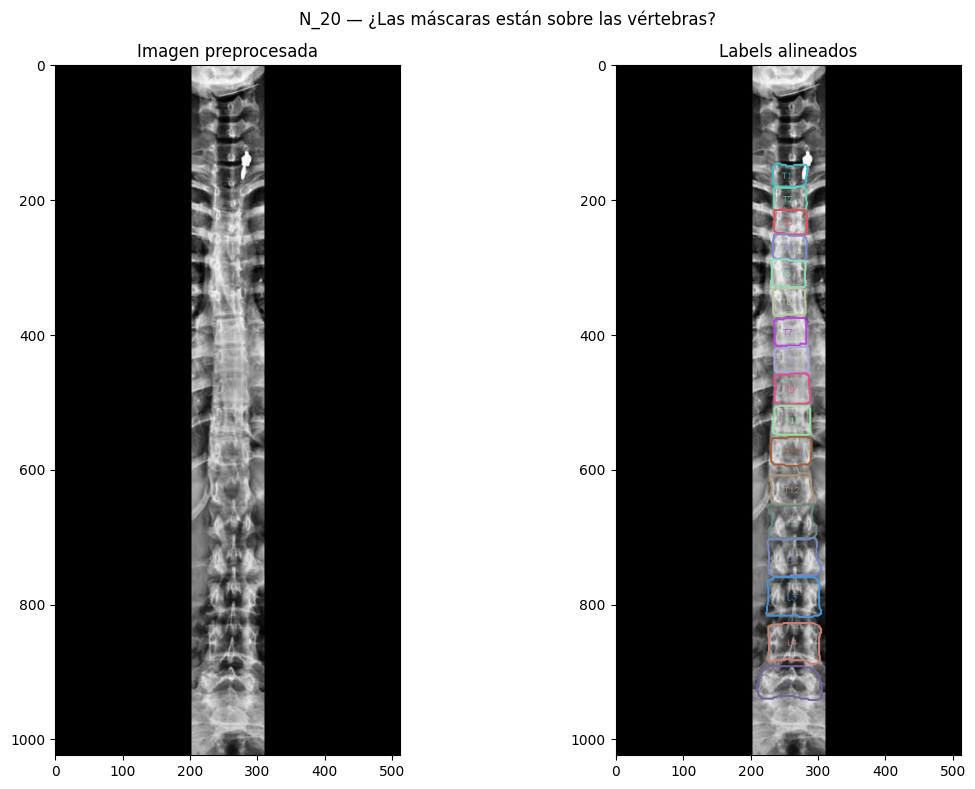

In [ ]:
# ── Verificación visual: imagen preprocesada + label alineado ─
# Si los contornos se ven sobre las vértebras correctas → continúa
import random as rnd

lbl_dir = YOLO_DS_E / 'labels' / 'train'
img_dir = YOLO_DS_E / 'images' / 'train'
sample_lbl = rnd.choice(list(lbl_dir.glob('*.txt')))
stem = sample_lbl.stem
img  = cv2.cvtColor(cv2.imread(str(img_dir / f'{stem}.jpg')), cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]

overlay = img.copy()
rng_pal = np.random.RandomState(0)
pal     = rng_pal.randint(60, 230, (NUM_CLASSES, 3), dtype=np.uint8)
with open(sample_lbl) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 7: continue
        cls = int(parts[0])
        pts = np.array(parts[1:], dtype=float).reshape(-1, 2)
        pts[:, 0] *= W; pts[:, 1] *= H
        pts = pts.astype(np.int32)
        col = tuple(int(x) for x in pal[cls])
        cv2.polylines(overlay, [pts], True, col, 2)
        M = cv2.moments(pts.reshape(-1,1,2).astype(np.float32))
        if M['m00'] > 0:
            cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])
            cv2.putText(overlay, CLASS_NAMES[cls], (cx-10, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, col, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(img);     axes[0].set_title('Imagen preprocesada')
axes[1].imshow(overlay); axes[1].set_title('Labels alineados')
plt.suptitle(f'{stem} — ¿Las máscaras están sobre las vértebras?')
plt.tight_layout(); plt.show()

In [ ]:
# ── data.yaml para cada dataset ───────────────────────────────
YAML_E = YOLO_DS_E / 'data.yaml'
YAML_E.write_text(f"""path: {YOLO_DS_E}
train: images/train
val:   images/val
test:  images/test
nc: {NUM_CLASSES}
names: {CLASS_NAMES}
""")

YAML_F = YOLO_DS_F / 'data.yaml'
YAML_F.write_text(f"""path: {YOLO_DS_F}
train: images/train
val:   images/val
test:  images/test
nc: {NUM_CLASSES}
names: {CLASS_NAMES}
""")

print('✔ data.yaml E y F listos')

✔ data.yaml E y F listos


---
## 5 — Entrenamiento

**Modelo E** — filtrado + preprocesamiento espinal  
**Modelo F** — completo + preprocesamiento espinal

Configuración idéntica al Modelo B original para comparación justa.
Las imágenes ya son `512×1024` así que `imgsz=1024` es correcto.

In [ ]:
print('=' * 60)
print('MODELO E — YOLOv8m filtrado + preprocesamiento espinal')
print('=' * 60)
model_e = YOLO('yolov8m-seg.pt')
model_e.train(
    data      = str(YAML_E),
    epochs    = 100,
    imgsz     = 1024,
    batch     = 8,
    lr0       = 0.001,
    lrf       = 0.01,
    degrees   = 15.0,    # rotación ±15° — útil para escoliosis
    fliplr    = 0.5,
    flipud    = 0.0,     # NO flipear verticalmente (columna tiene orientación)
    hsv_v     = 0.2,     # variación de brillo
    hsv_s     = 0.0,     # sin variación de saturación (es grayscale)
    mosaic    = 0.3,
    mixup     = 0.0,
    seed      = SEED,
    project   = str(RUNS_DIR),
    name      = 'E_filtrado_preproc',
    exist_ok  = True,
    val       = True,
)
print('✔ Modelo E completado')

MODELO E — YOLOv8m filtrado + preprocesamiento espinal
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_preproc/dataset_E/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.0, hsv_v=0.2, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=E_filtrado_preproc, nbs=64, n

In [ ]:
print('=' * 60)
print('MODELO F — YOLOv8m completo + preprocesamiento espinal')
print('=' * 60)
model_f = YOLO('yolov8m-seg.pt')
model_f.train(
    data      = str(YAML_F),
    epochs    = 100,
    imgsz     = 1024,
    batch     = 8,
    lr0       = 0.001,
    lrf       = 0.01,
    degrees   = 15.0,
    fliplr    = 0.5,
    flipud    = 0.0,
    hsv_v     = 0.2,
    hsv_s     = 0.0,
    mosaic    = 0.3,
    mixup     = 0.0,
    seed      = SEED,
    project   = str(RUNS_DIR),
    name      = 'F_completo_preproc',
    exist_ok  = True,
    val       = True,
)
print('✔ Modelo F completado')

MODELO F — YOLOv8m completo + preprocesamiento espinal
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_preproc/dataset_F/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.0, hsv_v=0.2, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=F_completo_preproc, nbs=64, n

---
## 6 — Evaluación Dice e IoU por clase

In [ ]:
# Cargar mejores modelos
best_e = RUNS_DIR / 'E_filtrado_preproc' / 'weights' / 'best.pt'
best_f = RUNS_DIR / 'F_completo_preproc' / 'weights' / 'best.pt'
model_e_best = YOLO(str(best_e))
model_f_best = YOLO(str(best_f))
print(f'✔ Modelo E: {best_e}')
print(f'✔ Modelo F: {best_f}')

✔ Modelo E: /content/yolo_preproc/runs/E_filtrado_preproc/weights/best.pt
✔ Modelo F: /content/yolo_preproc/runs/F_completo_preproc/weights/best.pt


In [ ]:
def yolo_pred_to_masks(result, num_classes, H, W):
    """Convierte predicción YOLOv8 a diccionario de máscaras binarias."""
    pred = {c: np.zeros((H, W), dtype=np.uint8) for c in range(num_classes)}
    if result.masks is None: return pred
    masks_data = result.masks.data.cpu().numpy()  # (N, H_mask, W_mask)
    classes    = result.boxes.cls.cpu().numpy().astype(int)
    confs      = result.boxes.conf.cpu().numpy()
    for c in range(num_classes):
        idx = np.where(classes == c)[0]
        if len(idx) == 0: continue
        best_idx = idx[np.argmax(confs[idx])]
        m = masks_data[best_idx]
        m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
        pred[c] = (m > 0.5).astype(np.uint8)
    return pred


def gt_from_png_aligned(mask_path, binary_path, target_h=1024, target_w=512):
    """GT alineado al mismo preprocesamiento que las imágenes."""
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None: return {c: np.zeros((target_h, target_w), np.uint8) for c in range(NUM_CLASSES)}
    if m.ndim == 3: m = m[:,:,0]
    H_orig, W_orig = m.shape
    crop = compute_crop_params(binary_path, H_orig, W_orig)
    if crop is not None:
        x1, y1, x2, y2 = crop
        m = m[y1:y2, x1:x2]
    H_crop, W_crop = m.shape
    scale = min(target_w / W_crop, target_h / H_crop)
    new_w = int(W_crop * scale); new_h = int(H_crop * scale)
    m = cv2.resize(m, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((target_h, target_w), dtype=np.uint8)
    pad_y  = (target_h - new_h) // 2
    pad_x  = (target_w - new_w) // 2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = m
    return {c: (canvas == c+1).astype(np.uint8) for c in range(NUM_CLASSES)}


def dice_iou(p, g):
    p, g  = p.astype(bool), g.astype(bool)
    inter = (p & g).sum(); union = (p | g).sum()
    return (2*inter/(p.sum()+g.sum()) if (p.sum()+g.sum()) > 0 else 1.0,
            inter/union if union > 0 else 1.0)


def eval_yolo_preproc(model, split_df, model_name, conf=0.25):
    """
    Evalúa Dice e IoU para un modelo YOLOv8 entrenado con imágenes preprocesadas.
    La imagen de entrada pasa por el mismo preprocesamiento antes de la inferencia.
    El GT se alinea con el mismo crop+padding.
    """
    dice_cls = {c: [] for c in range(NUM_CLASSES)}
    iou_cls  = {c: [] for c in range(NUM_CLASSES)}
    l5_log   = []

    for _, row in split_df.iterrows():
        ip   = DATASET_ROOT / row[COL_IMAGE]
        mp   = DATASET_ROOT / row[COL_MASK]
        bp   = DATASET_ROOT / row[COL_BINARY]
        stem = ip.stem
        curve = load_spine_curve(stem)

        # Preprocesar imagen para inferencia
        proc = preprocess_image(ip, bp, curve, use_spine_map=True)
        if proc is None: continue
        H, W = proc.shape[:2]

        # GT alineado al mismo preprocesamiento
        gt = gt_from_png_aligned(mp, bp, target_h=H, target_w=W)

        # Inferencia
        results = model.predict(proc, conf=conf, verbose=False)
        pred    = yolo_pred_to_masks(results[0], NUM_CLASSES, H, W)

        for c in range(NUM_CLASSES):
            if gt[c].sum() == 0: continue
            d, iou = dice_iou(pred[c], gt[c])
            dice_cls[c].append(d); iou_cls[c].append(iou)
            if c == 16:
                l5_log.append({
                    'image'   : ip.name, 'model': model_name,
                    'split'   : 'Scoliosis' if stem.startswith('S_') else 'Normal',
                    'dice'    : d, 'iou': iou,
                    'gt_px'   : int(gt[c].sum()), 'pred_px': int(pred[c].sum()),
                    'detected': pred[c].sum() > 0
                })
    return dice_cls, iou_cls, l5_log


print('Evaluando Modelo E (filtrado+preproc)...')
dice_e, iou_e, l5_e = eval_yolo_preproc(model_e_best, test_f, 'E_YOLO_filt_preproc')

print('Evaluando Modelo F (completo+preproc)...')
dice_f, iou_f, l5_f = eval_yolo_preproc(model_f_best, test_f, 'F_YOLO_full_preproc')

print('✔ Listo')

Evaluando Modelo E (filtrado+preproc)...
Evaluando Modelo F (completo+preproc)...
✔ Listo


In [ ]:
# ── Tabla comparativa completa ────────────────────────────────
prev_csv = DRIVE_ROOT / 'models' / 'comparacion_3modelos.csv'
if prev_csv.exists():
    prev      = pd.read_csv(prev_csv)
    dice_a_v  = dict(zip(range(NUM_CLASSES), prev['dice_A'].values))
    dice_b_v  = dict(zip(range(NUM_CLASSES), prev['dice_B'].values))
    dice_bp_v = dict(zip(range(NUM_CLASSES), prev['dice_Bplus'].values))
    print('✔ A/B/B+ cargados desde CSV')
else:
    dice_a_v  = dict(zip(range(17),[0.7232,0.5733,0.4570,0.2800,0.2133,0.1447,
                                     0.1006,0.1128,0.0424,0.0608,0.1128,0.2002,
                                     0.2364,0.2216,0.3206,0.5331,0.3744]))
    dice_b_v  = dict(zip(range(17),[0.6687,0.5934,0.4228,0.2685,0.3287,0.2690,
                                     0.3083,0.2588,0.1873,0.2984,0.2777,0.3068,
                                     0.2980,0.3543,0.4224,0.4858,0.4041]))
    dice_bp_v = dict(zip(range(17),[0.6436,0.6033,0.4081,0.2482,0.2811,0.3270,
                                     0.4010,0.3487,0.2527,0.2793,0.3312,0.2560,
                                     0.2739,0.2447,0.3675,0.4192,0.2850]))
    print('Usando valores conocidos de A/B/B+')

print(f'\n{"Clase":<6} {"A":>7} {"B":>7} {"B+":>7} {"E-Filt":>8} {"F-Full":>8} {"Mejor":>6}')
print('─'*56)
rows = []
for c in range(NUM_CLASSES):
    da  = dice_a_v.get(c, 0.)
    db  = dice_b_v.get(c, 0.)
    dbp = dice_bp_v.get(c, 0.)
    de  = np.mean(dice_e[c]) if dice_e[c] else 0.
    df_ = np.mean(dice_f[c]) if dice_f[c] else 0.
    bl  = ['A','B','B+','E','F'][[da,db,dbp,de,df_].index(max(da,db,dbp,de,df_))]
    tag = ' ◄L5' if c == 16 else ''
    print(f'{CLASS_NAMES[c]:<6} {da:>7.4f} {db:>7.4f} {dbp:>7.4f} {de:>8.4f} {df_:>8.4f} {bl:>6}{tag}')
    rows.append({'clase':CLASS_NAMES[c],'dice_A':da,'dice_B':db,'dice_Bplus':dbp,
                 'dice_E':de,'dice_F':df_,'mejor':bl,
                 'iou_E':np.mean(iou_e[c]) if iou_e[c] else 0.,
                 'iou_F':np.mean(iou_f[c]) if iou_f[c] else 0.})

print('─'*56)
ma  = np.mean([r['dice_A']     for r in rows])
mb  = np.mean([r['dice_B']     for r in rows])
mbp = np.mean([r['dice_Bplus'] for r in rows])
me  = np.mean([r['dice_E']     for r in rows])
mf  = np.mean([r['dice_F']     for r in rows])
print(f'{"MEAN":<6} {ma:>7.4f} {mb:>7.4f} {mbp:>7.4f} {me:>8.4f} {mf:>8.4f}')
print(f'\n  A  YOLOv8 completo          : {ma:.4f}')
print(f'  B  YOLOv8 filtrado          : {mb:.4f}')
print(f'  B+ YOLOv8 filtrado+posic    : {mbp:.4f}')
print(f'  E  YOLOv8 filtrado+preproc  : {me:.4f}  Δ vs B: {me-mb:+.4f}')
print(f'  F  YOLOv8 completo+preproc  : {mf:.4f}  Δ vs A: {mf-ma:+.4f}')
print(f'  Paper anterior              : 0.7400')
print(f'\n  Impacto preprocesamiento en YOLOv8 filtrado (B→E): {me-mb:+.4f}')
print(f'  Impacto preprocesamiento en YOLOv8 completo (A→F): {mf-ma:+.4f}')

import pandas as pd
pd.DataFrame(rows).to_csv(DRIVE_ROOT/'models'/'comparacion_EF.csv', index=False)
print('\n✔ Tabla guardada')

✔ A/B/B+ cargados desde CSV

Clase        A       B      B+   E-Filt   F-Full  Mejor
────────────────────────────────────────────────────────
T1      0.7232  0.6687  0.6436   0.5766   0.6424      A
T2      0.5733  0.5934  0.6033   0.5193   0.6625      F
T3      0.4570  0.4228  0.4081   0.4403   0.3686      A
T4      0.2800  0.2685  0.2482   0.3798   0.4181      F
T5      0.2133  0.3287  0.2811   0.4507   0.2961      E
T6      0.1447  0.2690  0.3270   0.3319   0.0774      E
T7      0.1006  0.3083  0.4010   0.2913   0.2210     B+
T8      0.1128  0.2588  0.3487   0.2762   0.2951     B+
T9      0.0424  0.1873  0.2527   0.2206   0.1449     B+
T10     0.0608  0.2984  0.2793   0.2612   0.2223      B
T11     0.1128  0.2777  0.3312   0.2707   0.2227     B+
T12     0.2002  0.3068  0.2560   0.3216   0.1556      E
L1      0.2364  0.2980  0.2739   0.2966   0.1834      B
L2      0.2216  0.3543  0.2447   0.3218   0.3455      B
L3      0.3206  0.4224  0.3675   0.2719   0.4048      B
L4      0.5331  0.

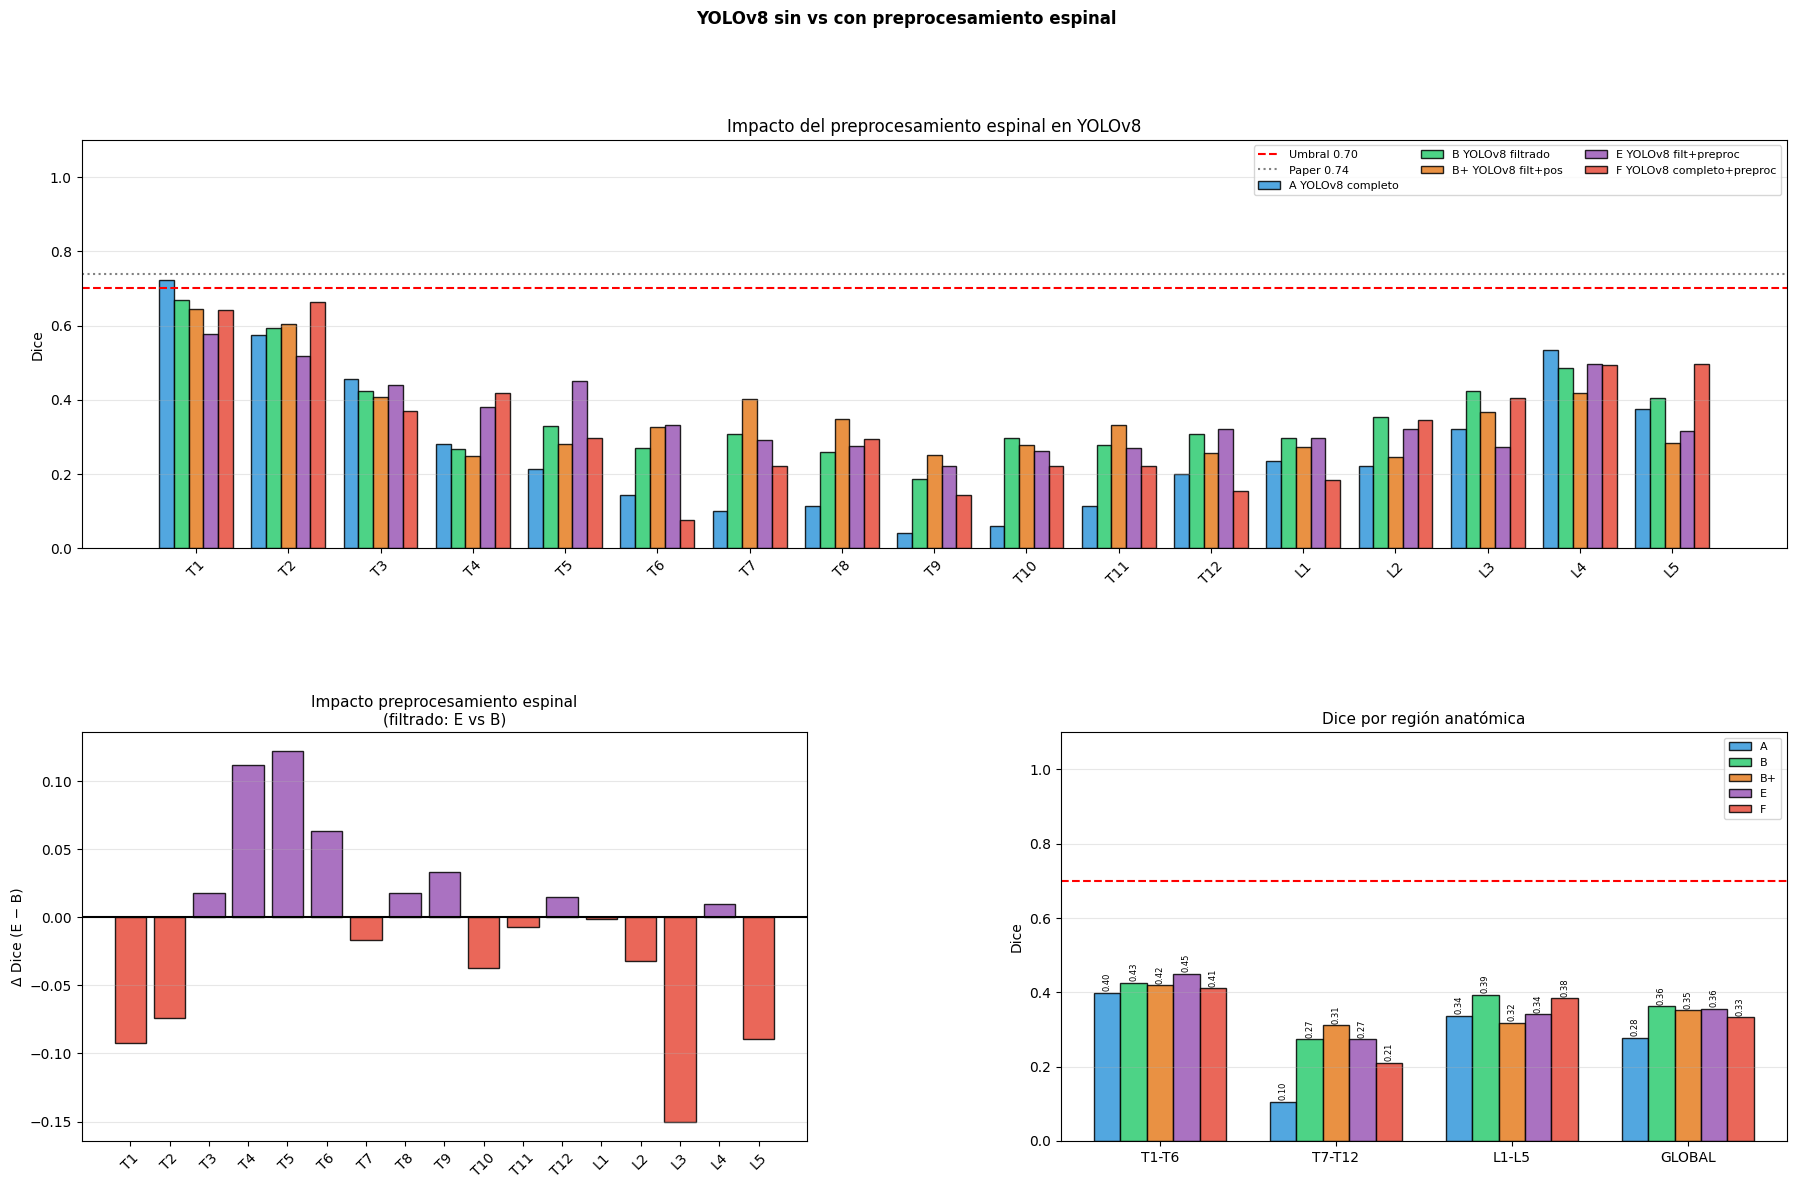

✔ Gráfico guardado


In [ ]:
# ── Gráfico comparativo ───────────────────────────────────────
fig = plt.figure(figsize=(22, 13))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
x = np.arange(NUM_CLASSES); w = 0.16

ax1 = fig.add_subplot(gs[0,:])
for off, (lbl, col, vals) in enumerate([
    ('A YOLOv8 completo',          '#3498db', [r['dice_A']     for r in rows]),
    ('B YOLOv8 filtrado',          '#2ecc71', [r['dice_B']     for r in rows]),
    ('B+ YOLOv8 filt+pos',         '#e67e22', [r['dice_Bplus'] for r in rows]),
    ('E YOLOv8 filt+preproc',      '#9b59b6', [r['dice_E']     for r in rows]),
    ('F YOLOv8 completo+preproc',  '#e74c3c', [r['dice_F']     for r in rows]),
]):
    ax1.bar(x+(off-2)*w, vals, w, label=lbl, color=col, alpha=0.85, edgecolor='k')
ax1.axhline(0.70, color='red',  ls='--', lw=1.5, label='Umbral 0.70')
ax1.axhline(0.74, color='gray', ls=':',  lw=1.5, label='Paper 0.74')
ax1.set_xticks(x); ax1.set_xticklabels(CLASS_NAMES, rotation=45)
ax1.set_ylabel('Dice'); ax1.set_ylim(0, 1.1)
ax1.set_title('Impacto del preprocesamiento espinal en YOLOv8', fontsize=12)
ax1.legend(fontsize=8, ncol=3); ax1.grid(axis='y', alpha=0.3)

# Delta E - B (impacto del preprocesamiento en filtrado)
ax2 = fig.add_subplot(gs[1,0])
delta_eb = [rows[c]['dice_E'] - rows[c]['dice_B'] for c in range(NUM_CLASSES)]
ax2.bar(x, delta_eb, color=['#9b59b6' if d>=0 else '#e74c3c' for d in delta_eb],
        edgecolor='k', alpha=0.85)
ax2.axhline(0, color='black', lw=1.5)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES, rotation=45)
ax2.set_ylabel('Δ Dice (E − B)')
ax2.set_title('Impacto preprocesamiento espinal\n(filtrado: E vs B)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Región anatómica
ax3 = fig.add_subplot(gs[1,1])
groups = {'T1-T6':range(0,6),'T7-T12':range(6,12),'L1-L5':range(12,17),'GLOBAL':range(0,17)}
xg = np.arange(len(groups)); wg = 0.15
de_v = {c: np.mean(dice_e[c]) if dice_e[c] else 0. for c in range(NUM_CLASSES)}
df_v = {c: np.mean(dice_f[c]) if dice_f[c] else 0. for c in range(NUM_CLASSES)}
for off2, (lbl, col, vd) in enumerate([
    ('A','#3498db',dice_a_v),('B','#2ecc71',dice_b_v),
    ('B+','#e67e22',dice_bp_v),('E','#9b59b6',de_v),('F','#e74c3c',df_v)
]):
    yv = [np.mean([vd.get(c,0) for c in rng]) for rng in groups.values()]
    bars = ax3.bar(xg+(off2-2)*wg, yv, wg, label=lbl, color=col, alpha=0.85, edgecolor='k')
    for bar, v in zip(bars, yv):
        ax3.text(bar.get_x()+bar.get_width()/2, v+0.01,
                 f'{v:.2f}', ha='center', fontsize=6, rotation=90)
ax3.axhline(0.70, color='red', ls='--', lw=1.5)
ax3.set_xticks(xg); ax3.set_xticklabels(list(groups.keys()))
ax3.set_ylabel('Dice'); ax3.set_ylim(0,1.1)
ax3.set_title('Dice por región anatómica', fontsize=11)
ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

plt.suptitle('YOLOv8 sin vs con preprocesamiento espinal',
             fontsize=12, fontweight='bold')
plt.savefig(str(DRIVE_ROOT/'models'/'comparacion_EF.png'), dpi=150, bbox_inches='tight')
plt.show(); print('✔ Gráfico guardado')

═══ L5 — Modelos E y F ═══════════════════════════════
                       dice                 detected
                       mean  median     std     mean
model                                               
E_YOLO_filt_preproc  0.3148  0.0000  0.4087      0.5
F_YOLO_full_preproc  0.4953  0.7164  0.4316      0.6

Por tipo de columna:
                                 mean  median  count
model               split                           
E_YOLO_filt_preproc Normal     0.3080  0.0000      8
                    Scoliosis  0.3422  0.3422      2
F_YOLO_full_preproc Normal     0.6191  0.7965      8
                    Scoliosis  0.0000  0.0000      2


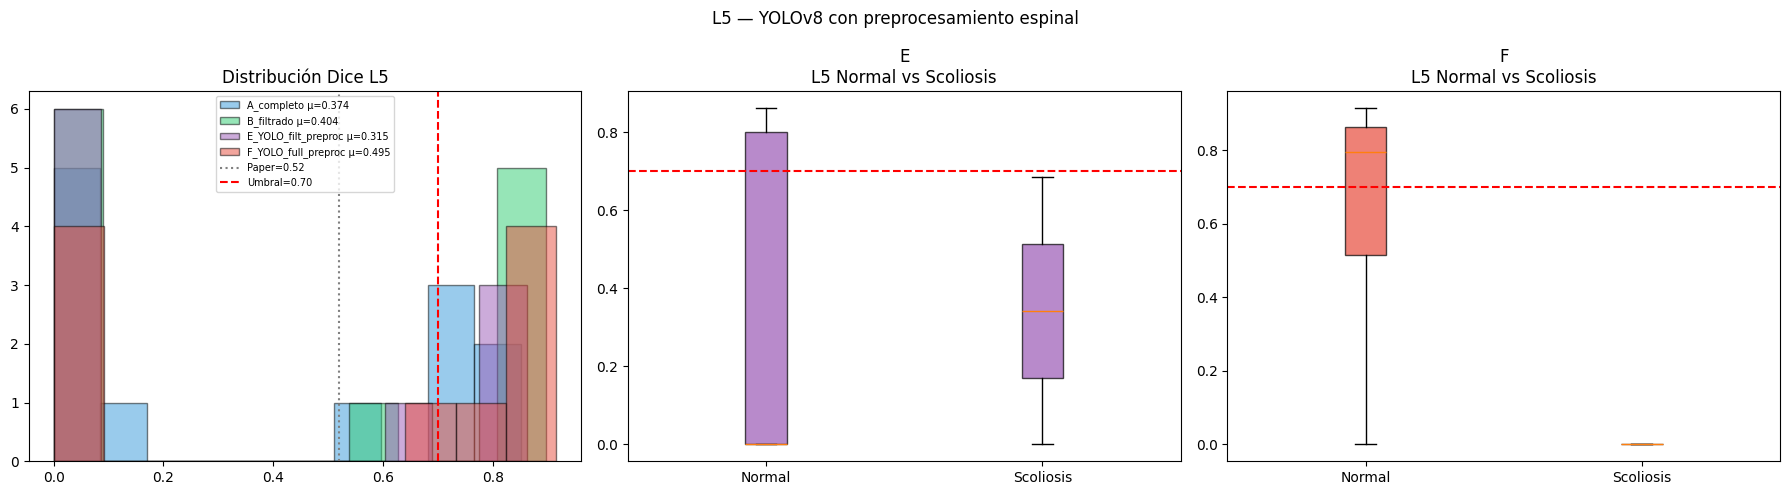

✔ Análisis L5 guardado


In [ ]:
# ── Análisis L5 ───────────────────────────────────────────────
if l5_e or l5_f:
    l5_ef = pd.DataFrame(l5_e + l5_f)
    print('═══ L5 — Modelos E y F ═══════════════════════════════')
    print(l5_ef.groupby('model')[['dice','detected']].agg(
        {'dice':['mean','median','std'],'detected':'mean'}
    ).round(4).to_string())
    print()
    print('Por tipo de columna:')
    print(l5_ef.groupby(['model','split'])['dice'].agg(
        ['mean','median','count']
    ).round(4).to_string())

    prev_l5 = DRIVE_ROOT / 'models' / 'l5_comparacion.csv'
    l5_all  = pd.concat([pd.read_csv(prev_l5), l5_ef], ignore_index=True) \
              if prev_l5.exists() else l5_ef
    l5_all.to_csv(DRIVE_ROOT/'models'/'l5_EF.csv', index=False)

    # Gráfico L5
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {'A_completo':'#3498db','B_filtrado':'#2ecc71',
              'E_YOLO_filt_preproc':'#9b59b6','F_YOLO_full_preproc':'#e74c3c'}
    for mdl in l5_all['model'].unique():
        sub = l5_all[l5_all['model']==mdl]['dice']
        axes[0].hist(sub, bins=10, alpha=0.5, edgecolor='k',
                     color=colors.get(mdl,'gray'), label=f'{mdl} μ={sub.mean():.3f}')
    axes[0].axvline(0.52, color='gray', ls=':', lw=1.5, label='Paper=0.52')
    axes[0].axvline(0.70, color='red',  ls='--',lw=1.5, label='Umbral=0.70')
    axes[0].set_title('Distribución Dice L5'); axes[0].legend(fontsize=7)

    for idx, (mdl, col) in enumerate([
        ('E_YOLO_filt_preproc','#9b59b6'), ('F_YOLO_full_preproc','#e74c3c')
    ]):
        sub_m = l5_ef[l5_ef['model']==mdl]
        if len(sub_m) == 0: continue
        bp = axes[idx+1].boxplot(
            [sub_m[sub_m['split']=='Normal']['dice'].values,
             sub_m[sub_m['split']=='Scoliosis']['dice'].values],
            labels=['Normal','Scoliosis'], patch_artist=True)
        for box in bp['boxes']: box.set_facecolor(col); box.set_alpha(0.7)
        axes[idx+1].axhline(0.70, color='red', ls='--', lw=1.5)
        axes[idx+1].set_title(f'{mdl.split("_")[0]}\nL5 Normal vs Scoliosis')
    plt.suptitle('L5 — YOLOv8 con preprocesamiento espinal')
    plt.tight_layout()
    plt.savefig(str(DRIVE_ROOT/'models'/'l5_EF.png'), dpi=150, bbox_inches='tight')
    plt.show(); print('✔ Análisis L5 guardado')

In [ ]:
# ── Guardar modelos y resumen ─────────────────────────────────
import shutil
save_dir = DRIVE_ROOT / 'models'
save_dir.mkdir(exist_ok=True)
shutil.copy(best_e, save_dir / 'yolov8m_E_filtrado_preproc_best.pt')
shutil.copy(best_f, save_dir / 'yolov8m_F_completo_preproc_best.pt')
print('✔ Modelos E y F guardados en Drive')

def rmean(vd, rng): return np.mean([vd.get(c,0) for c in rng])
l5e_m = pd.DataFrame(l5_e)['dice'].mean() if l5_e else 0.
l5f_m = pd.DataFrame(l5_f)['dice'].mean() if l5_f else 0.

print('\n'+'='*70)
print('RESUMEN — Modelos YOLOv8 con preprocesamiento espinal')
print('='*70)
print(f'''
A  YOLOv8m completo sin preproc    : {ma:.4f}
B  YOLOv8m filtrado sin preproc    : {mb:.4f}
B+ YOLOv8m filtrado+posicional     : {mbp:.4f}
E  YOLOv8m filtrado+preproc_espinal: {me:.4f}  Δ vs B: {me-mb:+.4f}
F  YOLOv8m completo+preproc_espinal: {mf:.4f}  Δ vs A: {mf-ma:+.4f}
Paper anterior                     : 0.7400

Impacto preprocesamiento espinal:
  En dataset filtrado (B→E): {me-mb:+.4f}
  En dataset completo (A→F): {mf-ma:+.4f}

Dice L5:
  E filtrado+preproc: {l5e_m:.4f}
  F completo+preproc: {l5f_m:.4f}
  B sin preproc:      {dice_b_v.get(16,0):.4f}
  Paper anterior:     0.5200

Lumbares (L1-L5):
  E: {rmean(de_v,range(12,17)):.4f}
  B: {rmean(dice_b_v,range(12,17)):.4f}
''')
print('='*70)

✔ Modelos E y F guardados en Drive

RESUMEN — Modelos YOLOv8 con preprocesamiento espinal

A  YOLOv8m completo sin preproc    : 0.2769
B  YOLOv8m filtrado sin preproc    : 0.3619
B+ YOLOv8m filtrado+posicional     : 0.3512
E  YOLOv8m filtrado+preproc_espinal: 0.3553  Δ vs B: -0.0066
F  YOLOv8m completo+preproc_espinal: 0.3323  Δ vs A: +0.0554
Paper anterior                     : 0.7400

Impacto preprocesamiento espinal:
  En dataset filtrado (B→E): -0.0066
  En dataset completo (A→F): +0.0554

Dice L5:
  E filtrado+preproc: 0.3148
  F completo+preproc: 0.4953
  B sin preproc:      0.4041
  Paper anterior:     0.5200

Lumbares (L1-L5):
  E: 0.3401
  B: 0.3929

